# Apartado 4. Estudio de la media y la varianza de la temperatura en dos grupos de celdas.

## Importación y carga de datos

En esta sección se importan los datos y librerías necesarias para el análisis del Apartado 1.

In [1]:
from carga_de_datos import *

Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 4.1. Basándote en las conclusiones del punto 2.2, forma dos grupos de celdas, de modo que las temperaturas de las celdas de un grupo sean similares entre sí y distintas a las del otro grupo. Justifica la elección de estos dos grupos.

Para contextualizar la elección de los dos grupos, vamos a mostrar el mismo análisis del apartado 2.2:

Matriz correlaciones:
              TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
TEMP_CELDA01       1.00000       0.99989       0.99956       0.99914   
TEMP_CELDA02       0.99989       1.00000       0.99988       0.99932   
TEMP_CELDA03       0.99956       0.99988       1.00000       0.99929   
TEMP_CELDA04       0.99914       0.99932       0.99929       1.00000   
TEMP_CELDA05       0.99868       0.99909       0.99933       0.99977   
TEMP_CELDA06       0.98676       0.98761       0.98828       0.98884   
TEMP_CELDA07       0.98137       0.98230       0.98305       0.98381   
TEMP_CELDA08       0.97699       0.97796       0.97874       0.97966   
TEMP_CELDA09       0.98409       0.98503       0.98589       0.98650   
TEMP_CELDA10       0.97975       0.98073       0.98158       0.98243   

              TEMP_CELDA05  TEMP_CELDA06  TEMP_CELDA07  TEMP_CELDA08  \
TEMP_CELDA01       0.99868       0.98676       0.98137       0.97699   
TEMP_CELDA02       0.99909       0.98761 

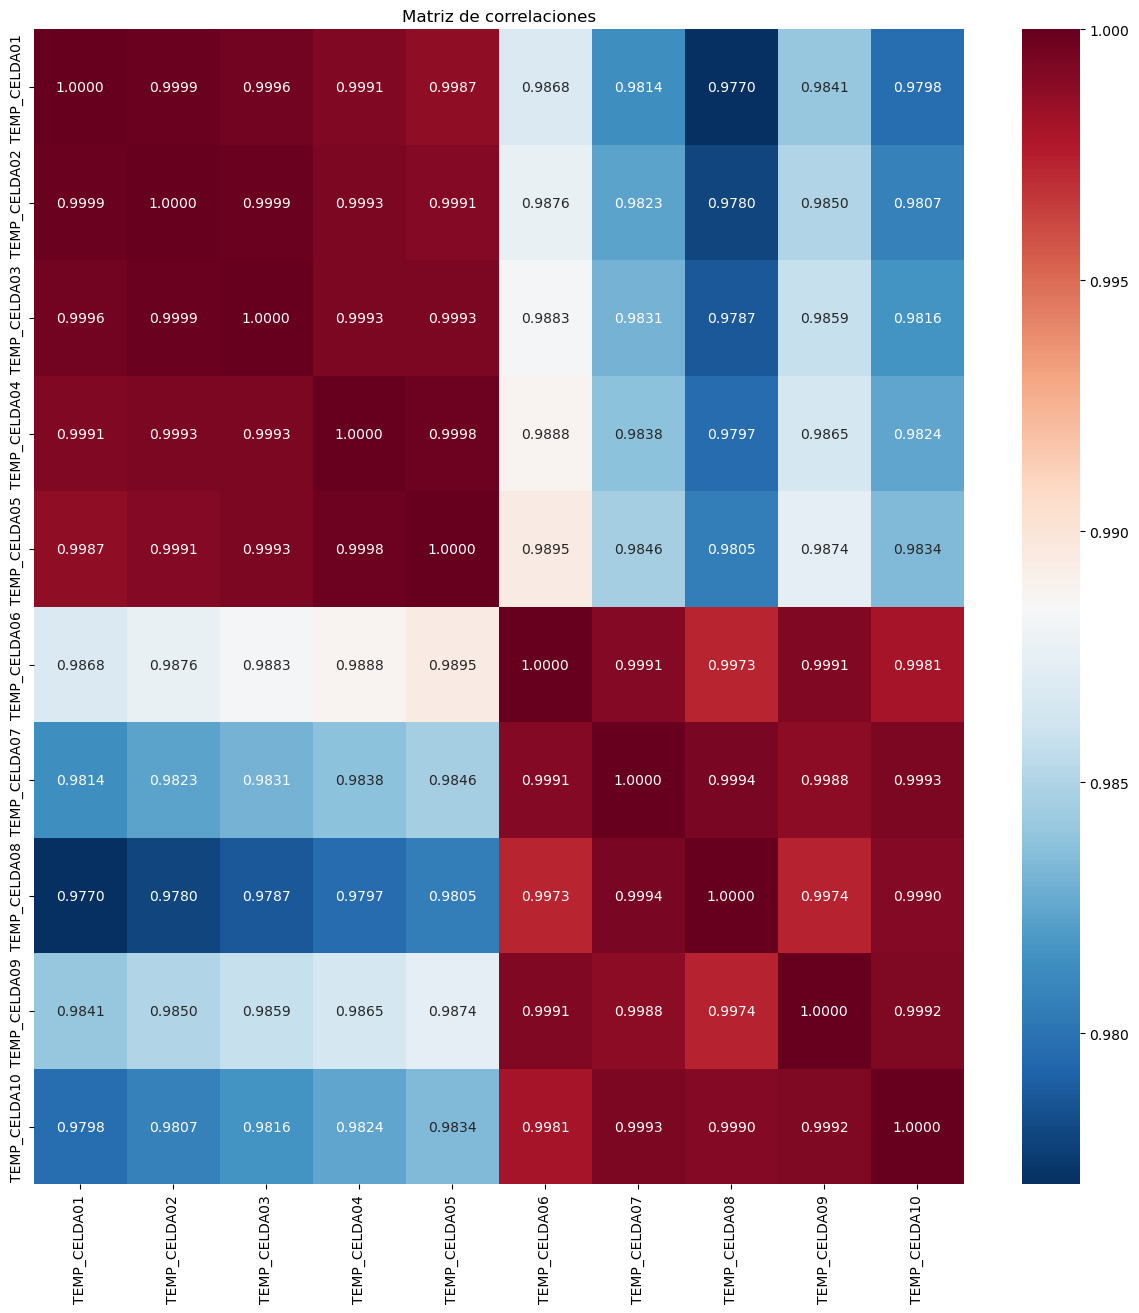

In [2]:
df_filtrado_temp = df_orig_temp.filter(like='CELDA')

# matriz de correlaciones
mat_corr = df_filtrado_temp.corr()                
print('Matriz correlaciones:')
print(np.round(mat_corr, 5)) 

# Muestra la matriz de correlaciones visualmente
fig = plt.figure(1,figsize=(15, 15))
sns.heatmap(mat_corr, annot=True, fmt='.4f', cmap='RdBu_r') # fmt para redondear a 4 decimales (porque si no la correlación sale como 1 en algunos casos)
plt.title('Matriz de correlaciones')
plt.show()

Podemos ver claramente como hay dos zonas distintas, una en rojo y la otra en blanco y azul. La primera zona está compuesta por las celdas 01-05, y la segunda compuesta por las celdas 06-10. Como ya habíamos empezado a indicar en apartados anteriores, seguramente esto se deba a que los datos elegidos sean de grupos de celdas de dos lugares geográficos diferentes.

## 4.2. Calcula las siguientes cuatro variables y explica cómo lo has hecho: la temperatura media y la varianza de la temperatura para cada uno de los dos grupos de celdas. Pista: cada una de estas cuatro variables es una serie temporal de datos diarios que abarca el rango de fechas original. ¿Qué grupo de celdas tiene las temperaturas más altas? ¿Y qué grupo tiene una temperatura más homogénea entre sus celdas? 

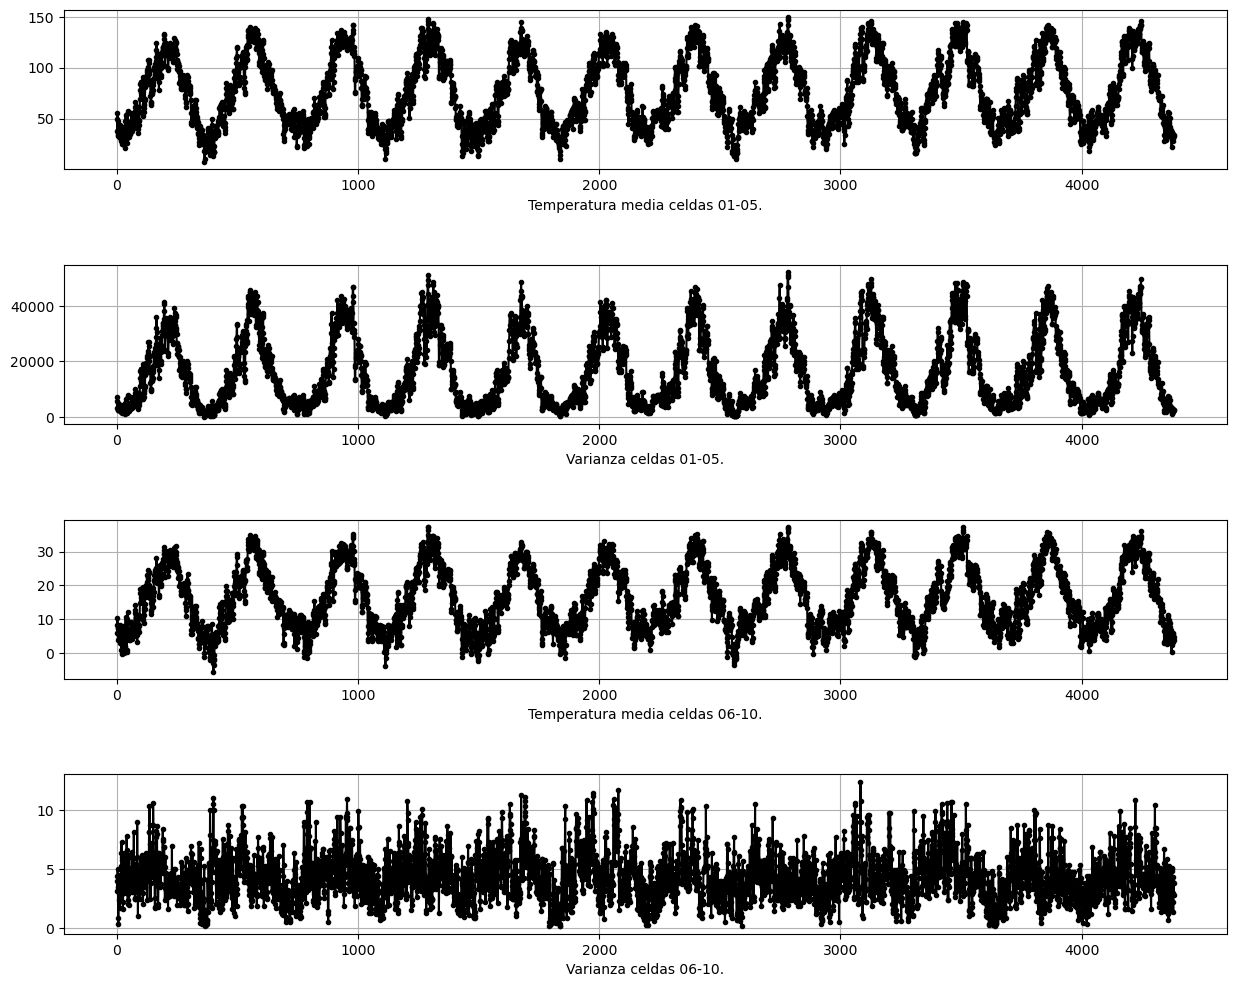

"fig = plt.figure(1, figsize=(15, 4))\nplt.plot(temp_media2, 'k.-')\nplt.grid()\nplt.show()\n\n\nfig = plt.figure(1, figsize=(15, 4))\nplt.plot(varianza_temp2, 'k.-')\nplt.grid()\nplt.show()"

In [ ]:
temp_media1 = df_orig_temp["TEMP_CELDA01"].copy()
for i in range(2, 6):
    temp_media1 += df_orig_temp[f"TEMP_CELDA0{i}"]
temp_media1 = temp_media1 / 5

varianza_temp1 = []
for i in range(len(df_orig_temp["TEMP_CELDA01"])):
    x = []
    for j in range(1, 6):
        x.append(df_orig_temp[f"TEMP_CELDA0{j}"].iloc[i])
    varianza_temp1.append(np.var(x))



temp_media2 = df_orig_temp["TEMP_CELDA10"].copy()
for i in range(5, 10):
    temp_media2 += df_orig_temp[f"TEMP_CELDA0{i}"]
temp_media2 = temp_media2 / 5

varianza_temp2 = []
for i in range(len(df_orig_temp["TEMP_CELDA05"])):
    x = []
    for j in range(5, 10):
        x.append(df_orig_temp[f"TEMP_CELDA0{j}"].iloc[i])
    x.append(df_orig_temp[f"TEMP_CELDA10"].iloc[i])
    varianza_temp2.append(np.var(x))


fig, axs = plt.subplots(4, 1, figsize=(15, 12))
fig.subplots_adjust(hspace=0.6)

plots = [temp_media1, varianza_temp1, temp_media2, varianza_temp2]
names = ["Temperatura media celdas 01-05.", "Varianza celdas 01-05.", "Temperatura media celdas 06-10.", "Varianza celdas 06-10."]

for i in range(4):
    axs[i].plot(plots[i], 'k.-')
    axs[i].set_xlabel(names[i])
    axs[i].grid()
plt.show()